<a href="https://colab.research.google.com/github/SpaceBites/Illegal-forest-detection-/blob/main/Titanic_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_graphviz
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import graphviz


In [ ]:
df = pd.read_csv("Titanic.csv")

print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [ ]:
#Selecting Feature
df = df[[
    "Survived",
    "Pclass",
    "Sex",
    "Age",
    "Fare"
]]


In [ ]:
#Handling missing data (using median to fill the missing value with avg age)
df["Age"] = df["Age"].fillna(df["Age"].median())


In [ ]:
df["Sex"] = df["Sex"].map({
    "male": 0,
    "female": 1
}) #defining Male and Female

In [ ]:
X = df.drop("Survived", axis=1) #Removing Target

y = df["Survived"] #selceting target

In [ ]:
#Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)

In [ ]:
#Decision Tree
tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    min_samples_leaf=5,
    random_state=42
)

tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, min_samples_leaf=5, random_state=42)

In [ ]:
#decision tree acurracy
y_pred = tree.predict(X_test)

tree_accuracy = accuracy_score(y_test, y_pred)

print("\nDecision Tree Accuracy:")
print(tree_accuracy)


Decision Tree Accuracy:
0.7988826815642458


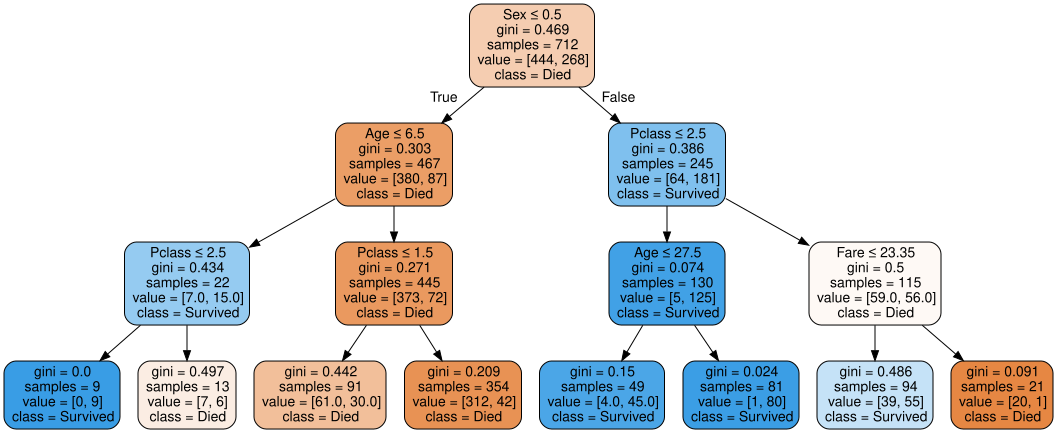

In [ ]:
#decison tree grapg
dot_data = export_graphviz(
    tree,
    out_file=None,
    feature_names=X.columns,
    class_names=["Died", "Survived"],
    filled=True,
    rounded=True,
    special_characters=True
)

graph = graphviz.Source(dot_data)

graph.render("titanic_decision_tree")

graph

In [ ]:
#Random forest
forest = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_leaf=5,
    oob_score=True,
    random_state=42
)

forest.fit(X_train, y_train)


RandomForestClassifier(max_depth=5, min_samples_leaf=5, oob_score=True,
                       random_state=42)

In [ ]:
#Random forest accuracy
rf_pred = forest.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("\nRandom Forest Accuracy:")
print(rf_accuracy)


Random Forest Accuracy:
0.7988826815642458


In [ ]:
#OOB score (use as a vlidation data, for testinf )
print("\nOut-of-Bag Score:")
print(forest.oob_score_)



Out-of-Bag Score:
0.8286516853932584


In [ ]:
#Feature importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": forest.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance:")
print(importance)


Feature Importance:
  Feature  Importance
1     Sex    0.534057
3    Fare    0.176707
0  Pclass    0.160619
2     Age    0.128617


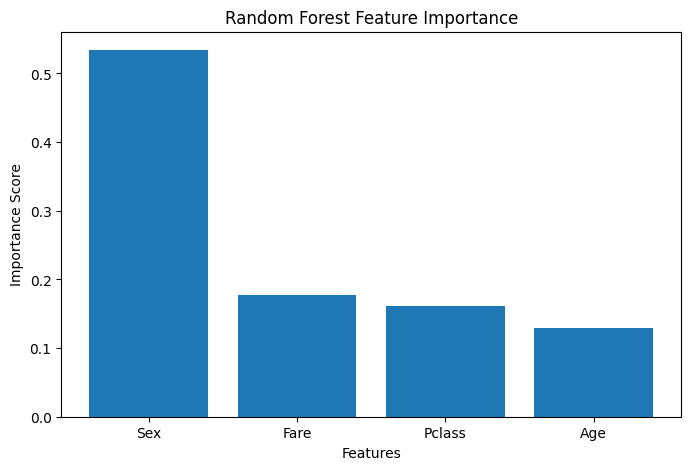

In [ ]:
#Feature importance graph/plot
plt.figure(figsize=(8, 5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Random Forest Feature Importance")

plt.xlabel("Features")

plt.ylabel("Importance Score")

plt.show()